In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import pandas as pd

In [10]:
# Load EfficientNetB0 with pretrained ImageNet weights, excluding the top classification layer
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model weights (optional, useful for transfer learning)
base_model.trainable = False

# Build the new model
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(23, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,079,034 (15.56 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
logos = pd.read_csv("../data/sector_small.csv")
logos.head()

,name,domain,sector,filepath
0,engecorps,engecorps.com.br,Construction & Infrastructure,/Users/armankassam/dis/ann/logo-classifier/dat...
1,eksjöhus ab,eksjohus.se,Construction & Infrastructure,/Users/armankassam/dis/ann/logo-classifier/dat...
2,orbenk administração e serviços ltda,orbenk.com.br,Construction & Infrastructure,/Users/armankassam/dis/ann/logo-classifier/dat...
3,webcor builders,webcor.com,Construction & Infrastructure,/Users/armankassam/dis/ann/logo-classifier/dat...
4,boes construction,boesconstruction.com,Construction & Infrastructure,/Users/armankassam/dis/ann/logo-classifier/dat...


In [ ]:
label_to_idx = {label: i for i, label in enumerate(sorted(logos['sector'].unique()))}
image_paths = ('../data/academic/' + logos['domain'] + '.png').values
labels = logos['sector'].map(label_to_idx).values

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32)
    return img, label

dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.map(load_image).batch(32)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.cfit(dataset, epochs=10)

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 42s 280ms/step - accuracy: 0.0045 - loss: 4.7801
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 42s 307ms/step - accuracy: 0.0061 - loss: 3.9183
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 45s 327ms/step - accuracy: 0.0077 - loss: 3.9472
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 46s 331ms/step - accuracy: 0.0125 - loss: 3.8958
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 48s 346ms/step - accuracy: 0.0143 - loss: 3.8467
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 376ms/step - accuracy: 0.0209 - loss: 3.8054
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 49s 358ms/step - accuracy: 0.0264 - loss: 3.7749
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 48s 344ms/step - accuracy: 0.0298 - loss: 3.7311
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 48s 344ms/step - accuracy: 0.0368 - loss: 3.7046
Epoch 10/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 47s 343ms/step - accuracy: 0.0425 - loss: 3.6764


138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 281ms/step


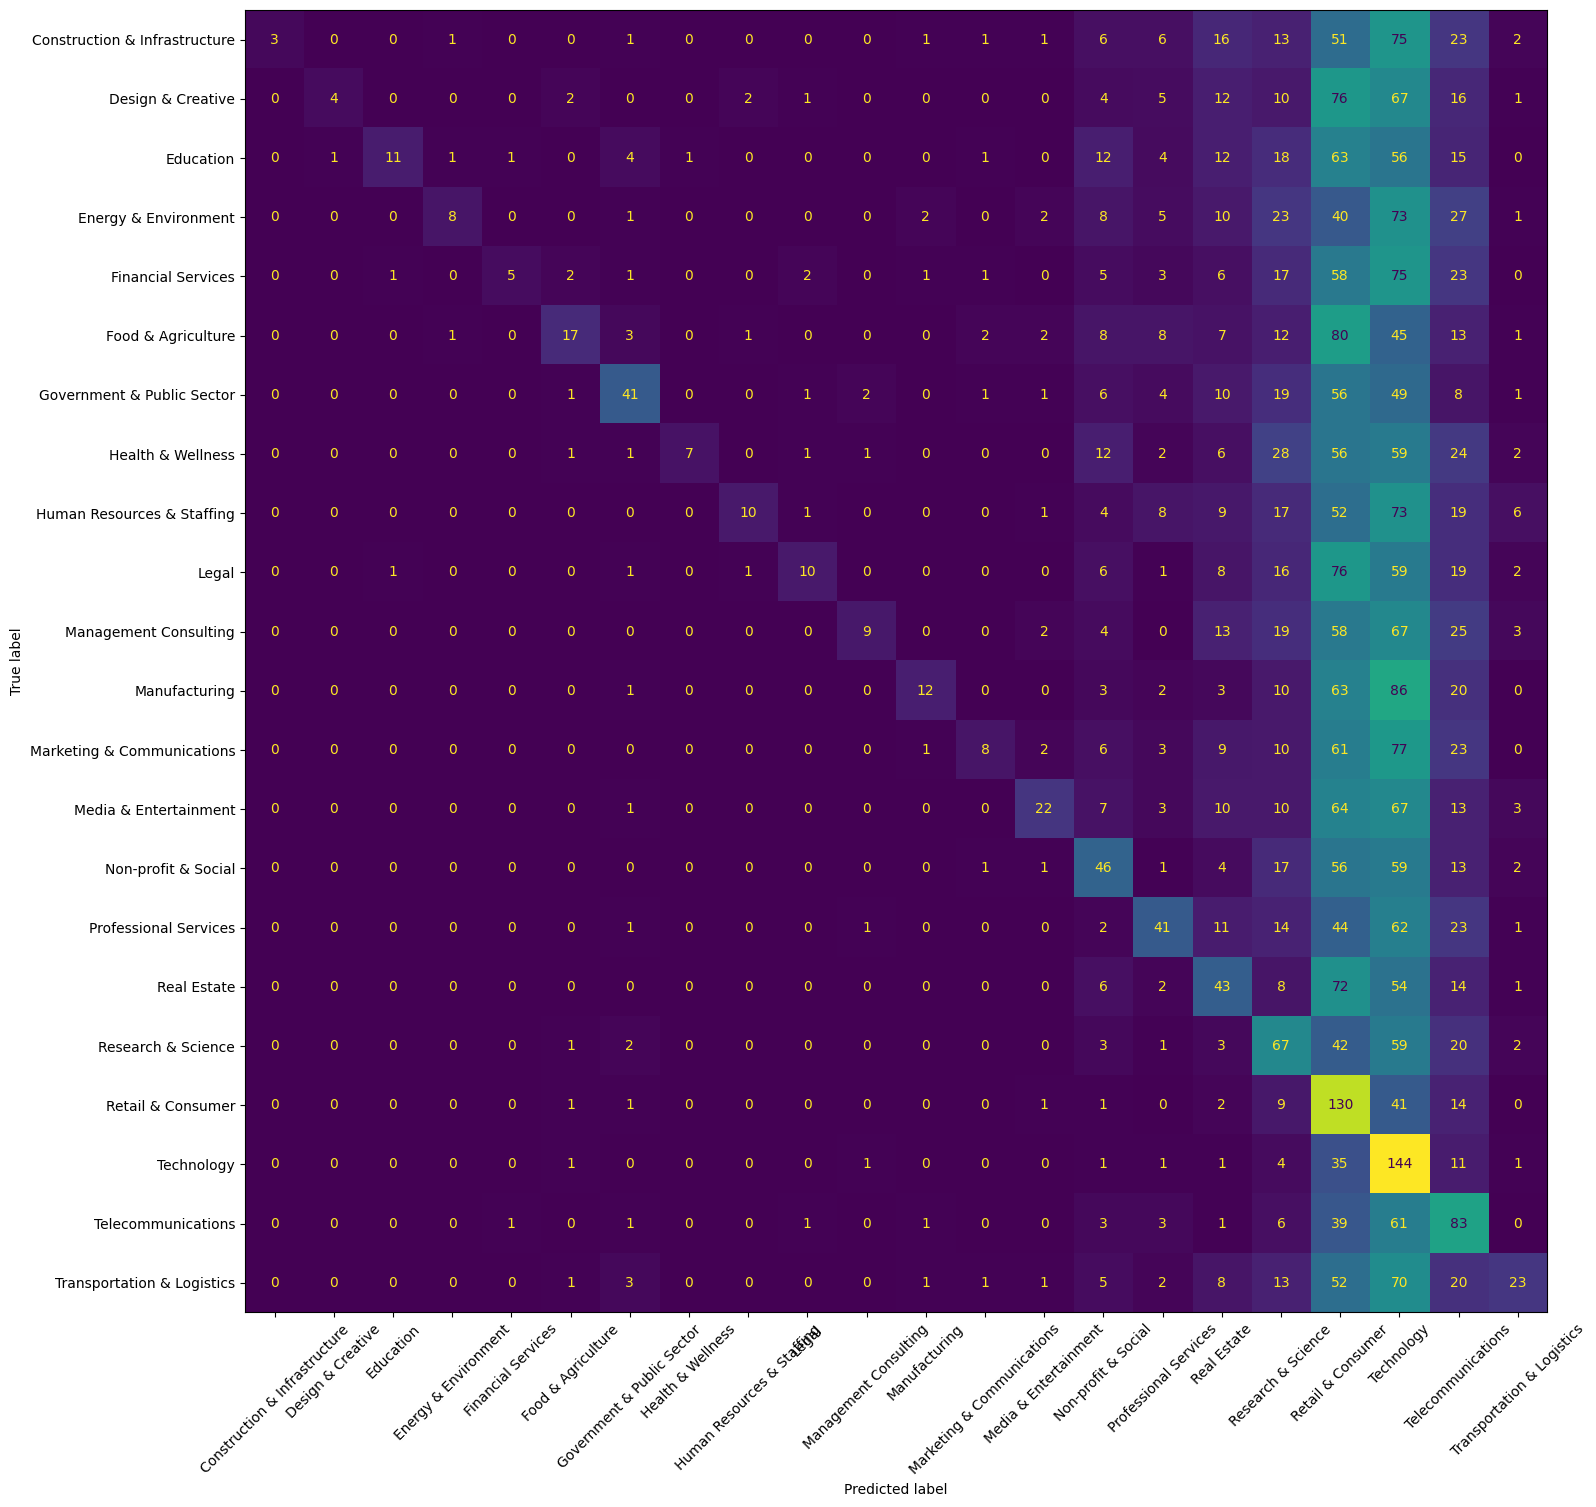

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
preds = model.predict(dataset).argmax(axis=1)
true_labels = labels  # your existing labels array

# Create and plot
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=list(label_to_idx.keys()))

fig, ax = plt.subplots(figsize=(16, 16))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()